In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
pip install yfinance

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
     ---------------------------------------- 0.0/949.2 kB ? eta -:--:--
     ----------- ---------------------------- 262.1/949.2 kB ? eta -:--:--
     -------------------------------------- 949.2/949.2 kB 2.7 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached pycparser-2.22-py3-none-any.whl.metadata (943 bytes)
  Using cached charset_normalizer-3.4.2-cp31


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install streamlit


  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached MarkupSafe-3.0.2-cp313-cp313-win_amd64.whl.metadata (4.1 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 1.6 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/9.9 MB 1.3 MB/s eta 0:00:08
   --- ------------------------------------ 0.8/9.9 MB 1.3 MB/s eta 0:00:08
   ---- ----------------------------------- 1.0/9.9 MB 1.1 MB/s eta 0:00:08
   ----- ---------------------------------- 1.3/9.9 MB 1.1 MB/s eta 0:00:09
   ----- ---------------------------------- 1.3/9.9 MB 1.1 MB/s eta 0:00:09
   ------ --------------------------------- 1.6/9.9 MB 1.0 MB/s eta 0:00:09
   ------- -------------------------------- 1.8/9.9 MB 1.0 MB/s eta 0:00:08
   -------- ------------------------------- 2.1/9.9 MB 1.0 MB/s eta 0:00:08
   --------- --------------------------


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Test Eval

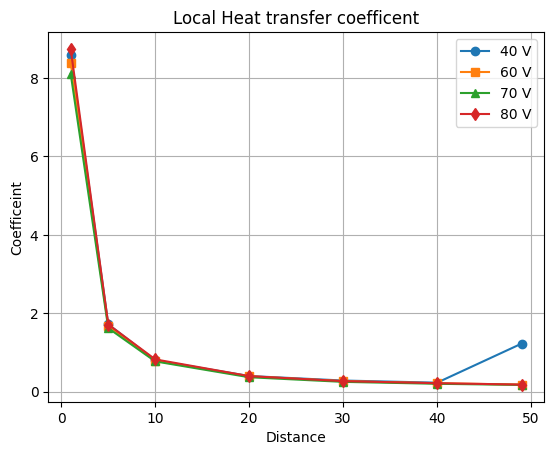

In [3]:
import matplotlib.pyplot as plt

# Example data
x = [1, 5, 10, 20, 30, 40, 49]
y1 = [8.589,
1.718,
0.802,
0.401,
0.286,
0.231,
1.227]
y2 = [8.386,
1.677,
0.788,
0.394,
0.271,
0.217,
0.183]
y3 = [8.105,
1.621,
0.774,
0.37,
0.252,
0.203,
0.174]
y4 = [8.738,
1.714,
0.825,
0.398,
0.270,
0.218,
0.182]

# Plot all Y datasets
plt.plot(x, y1, marker='o', label='40 V')
plt.plot(x, y2, marker='s', label='60 V')
plt.plot(x, y3, marker='^', label='70 V')
plt.plot(x, y4, marker='d', label='80 V')

# Labels and title
plt.xlabel("Distance")
plt.ylabel("Coefficeint")
plt.title("Local Heat transfer coefficent")
plt.grid(True)
plt.legend()  # Show legend
plt.show()


In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.preprocessing import MinMaxScaler

def generate_portfolio(tickers, risk_profile='Medium', start_date='2020-01-01', end_date='2024-12-31', rf_annual=0.065):
    rf_monthly = rf_annual / 12

    # STEP 1: Download data
    data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)
    monthly_prices = data['Close'].resample('ME').ffill()
    monthly_returns = monthly_prices.pct_change().dropna()

    market = yf.download('^NSEI', start=start_date, end=end_date, auto_adjust=True)
    market_prices = market['Close'].resample('ME').ffill()
    market_returns = market_prices.pct_change().dropna()

    # STEP 2: Align with market
    common_index = monthly_returns.index.intersection(market_returns.index)
    monthly_returns_aligned = monthly_returns.loc[common_index]
    market_returns_aligned = market_returns.loc[common_index]
    if isinstance(market_returns_aligned, pd.DataFrame):
        market_returns_aligned = market_returns_aligned.iloc[:, 0]

    # STEP 3: Split into Train (60%), Eval (20%), Test (20%)
    train_end = '2022-12-31'
    eval_end = '2023-12-31'

    train_returns = monthly_returns_aligned.loc[:train_end]
    eval_returns = monthly_returns_aligned.loc['2023-01-01':eval_end]
    test_returns = monthly_returns_aligned.loc['2024-01-01':]

    train_market = market_returns_aligned.loc[:train_end]
    eval_market = market_returns_aligned.loc['2023-01-01':eval_end]
    test_market = market_returns_aligned.loc['2024-01-01':]

    # STEP 4: Risk metrics from training data
    mean_return = train_returns.mean()
    std_dev = train_returns.std()
    cov_with_market = train_returns.apply(lambda x: x.cov(train_market))
    beta = cov_with_market / train_market.var()
    treynor = (mean_return - rf_monthly) / beta
    sharpe = (mean_return - rf_monthly) / std_dev

    z_95 = norm.ppf(0.05)
    z_99 = norm.ppf(0.01)
    VaR_95 = mean_return + z_95 * std_dev
    VaR_99 = mean_return + z_99 * std_dev

    # STEP 5: Remove highly correlated stocks
    corr_matrix = train_returns.corr()

    def remove_high_corr_stocks(corr_matrix, threshold=0.85):
        to_drop = set()
        for i in corr_matrix.columns:
            for j in corr_matrix.columns:
                if i != j and corr_matrix.loc[i, j] > threshold:
                    if sharpe[i] < sharpe[j]:
                        to_drop.add(i)
                    else:
                        to_drop.add(j)
        return list(to_drop)

    high_corr_stocks = remove_high_corr_stocks(corr_matrix)
    print("Removed due to high correlation:", high_corr_stocks)

    # Drop from all data
    for df in [train_returns, eval_returns, test_returns]:
        df.drop(columns=high_corr_stocks, inplace=True, errors='ignore')

    mean_return = mean_return.drop(high_corr_stocks)
    std_dev = std_dev.drop(high_corr_stocks)
    beta = beta.drop(high_corr_stocks)
    treynor = treynor.drop(high_corr_stocks)
    sharpe = sharpe.drop(high_corr_stocks)
    VaR_95 = VaR_95.drop(high_corr_stocks)
    VaR_99 = VaR_99.drop(high_corr_stocks)

    # STEP 6: Scoring and Weighting
    metrics_df = pd.DataFrame({
        'Return': mean_return,
        'Volatility': std_dev,
        'Beta': beta,
        'Sharpe': sharpe,
        'Treynor': treynor,
        'VaR_95': VaR_95,
        'VaR_99': VaR_99
    })
    metrics_df['-Beta'] = -metrics_df['Beta']
    metrics_df['-VaR_95'] = -metrics_df['VaR_95']
    metrics_df['-Volatility'] = -metrics_df['Volatility']

    if risk_profile == 'Low':
        metric_columns = ['Sharpe', '-Beta', '-VaR_95', '-Volatility']
    elif risk_profile == 'High':
        metric_columns = ['Return', 'Sharpe', 'Treynor']
    else:  # Medium
        metric_columns = ['Sharpe', 'Treynor', '-Beta', '-VaR_95']

    scaler = MinMaxScaler()
    norm_metrics = scaler.fit_transform(metrics_df[metric_columns])
    score = norm_metrics.mean(axis=1)
    weights = score / score.sum()

    # STEP 7: Evaluate Portfolio on EVAL and TEST sets
    def evaluate_portfolio(returns, market_returns, label):
        weighted_returns = returns @ weights
        portfolio_cum = (1 + weighted_returns).cumprod()
        market_cum = (1 + market_returns).cumprod()

        plt.figure(figsize=(10, 4))
        plt.plot(portfolio_cum, label='Portfolio')
        plt.plot(market_cum, label='NIFTY 50')
        plt.title(f"{label} Performance")
        plt.xlabel("Date")
        plt.ylabel("Cumulative Return")
        plt.legend()
        plt.grid(True)
        plt.show()

        port_ret = weighted_returns.mean()
        port_std = weighted_returns.std()
        sharpe_ratio = (port_ret - rf_monthly) / port_std

        print(f"\n--- {label} Metrics ---")
        print(f"Monthly Return: {port_ret*100:.2f}%")
        print(f"Monthly Volatility: {port_std*100:.2f}%")
        print(f"Monthly Sharpe Ratio: {sharpe_ratio:.4f}")
        print(f"Annual Return: {port_ret*12*100:.2f}%")
        print(f"Annual Volatility: {port_std*np.sqrt(12)*100:.2f}%")
        print(f"Annual Sharpe Ratio: {(port_ret*12 - rf_annual) / (port_std*np.sqrt(12)):.4f}")

    # Final display of selected metrics and weights
    df_to_display = metrics_df.copy()
    df_to_display[['Return', 'Volatility', 'VaR_95', 'VaR_99']] *= 100

    print("\n=== Final Stock Metrics (Train Data, in %) ===")
    print(df_to_display[['Return', 'Volatility', 'Beta', 'Sharpe', 'Treynor', 'VaR_95', 'VaR_99']].round(2))

    print("\n=== Portfolio Weights ===")
    print(pd.Series(weights, index=metrics_df.index).round(4))

    # Step 8: Evaluate
    evaluate_portfolio(eval_returns, eval_market, "Eval Period")
    evaluate_portfolio(test_returns, test_market, "Test Period")

    # Step 9: Final Correlation Heatmap
    plt.figure(figsize=(8,6))
    sns.heatmap(train_returns.corr(), annot=True, cmap='coolwarm')
    plt.title("Train Data Correlation Matrix (After Filtering)")
    plt.show()


ModuleNotFoundError: No module named 'scipy'

[*********************100%***********************]  6 of 6 completed
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_72/3090067715.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=high_corr_stocks, inplace=True, errors='ignore')
/tmp/ipykernel_72/3090067715.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=high_corr_stocks, inplace=True, errors='ignore')
/tmp/ipykernel_72/3090067715.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pa

Removed due to high correlation: []

=== Final Stock Metrics (Train Data, in %) ===
             Return  Volatility  Beta  Sharpe  Treynor  VaR_95  VaR_99
Ticker                                                                
HDFCBANK.NS    1.21        8.37  1.11    0.08     0.01  -12.56  -18.26
INFY.NS        2.48        8.93  0.81    0.22     0.02  -12.21  -18.29
ITC.NS         1.67        7.32  0.65    0.15     0.02  -10.37  -15.36
MRF.NS         0.97        7.67  0.60    0.06     0.01  -11.63  -16.86
RELIANCE.NS    2.18        9.62  0.98    0.17     0.02  -13.64  -20.19
TCS.NS         1.62        6.75  0.54    0.16     0.02   -9.47  -14.07

=== Portfolio Weights ===
Ticker
HDFCBANK.NS    0.0331
INFY.NS        0.3302
ITC.NS         0.1890
MRF.NS         0.0077
RELIANCE.NS    0.2329
TCS.NS         0.2071
dtype: float64


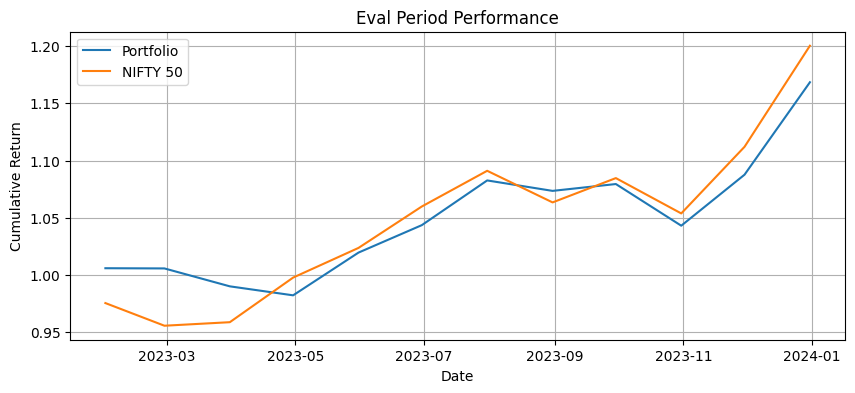


--- Eval Period Metrics ---
Monthly Return: 1.35%
Monthly Volatility: 3.04%
Monthly Sharpe Ratio: 0.2652
Annual Return: 16.16%
Annual Volatility: 10.51%
Annual Sharpe Ratio: 0.9188


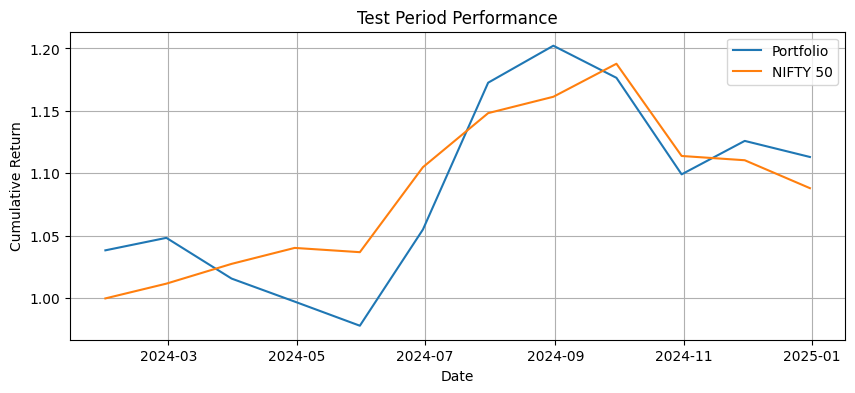


--- Test Period Metrics ---
Monthly Return: 1.01%
Monthly Volatility: 4.94%
Monthly Sharpe Ratio: 0.0939
Annual Return: 12.06%
Annual Volatility: 17.10%
Annual Sharpe Ratio: 0.3252


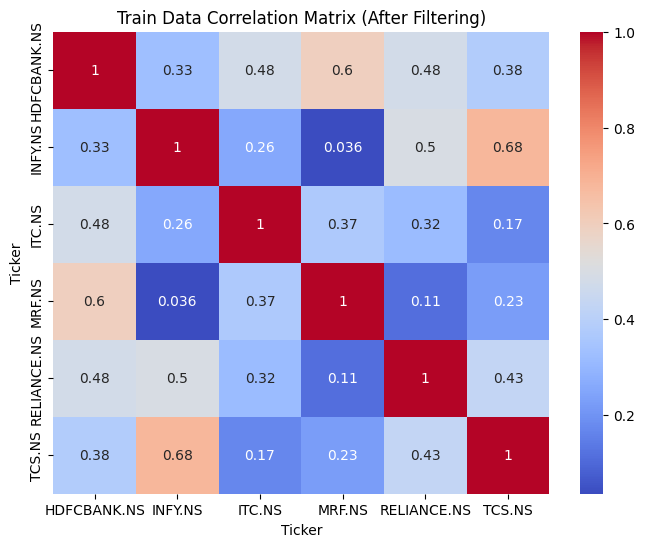

In [7]:
generate_portfolio(['HDFCBANK.NS', 'INFY.NS', 'ITC.NS', 'RELIANCE.NS', 'TCS.NS','MRF.NS'], risk_profile='High')


**Rolling Window**

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.preprocessing import MinMaxScaler

def generate_portfolio(tickers, risk_profile='Medium', start_date='2020-01-01', end_date='2024-12-31', rf_annual=0.065):
    rf_monthly = rf_annual / 12

    # STEP 1: Download data
    data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)
    monthly_prices = data['Close'].resample('ME').ffill()
    monthly_returns = monthly_prices.pct_change()
    monthly_returns = monthly_returns.dropna(how='all')
    monthly_returns = monthly_returns.dropna(axis=1, thresh=0.8*len(monthly_returns))  # keep only stocks with enough data

    market = yf.download('^NSEI', start=start_date, end=end_date, auto_adjust=True)
    market_prices = market['Close'].resample('ME').ffill()
    market_returns = market_prices.pct_change().dropna()

    # STEP 2: Align with market
    common_index = monthly_returns.index.intersection(market_returns.index)
    monthly_returns_aligned = monthly_returns.loc[common_index]
    market_returns_aligned = market_returns.loc[common_index]
    if isinstance(market_returns_aligned, pd.DataFrame):
        market_returns_aligned = market_returns_aligned.iloc[:, 0]

    # STEP 3: Split into Train (60%), Eval (20%), Test (20%)
    train_end = '2022-12-31'
    eval_end = '2023-12-31'

    train_returns = monthly_returns_aligned.loc[:train_end]
    eval_returns = monthly_returns_aligned.loc['2023-01-01':eval_end]
    test_returns = monthly_returns_aligned.loc['2024-01-01':]

    train_market = market_returns_aligned.loc[:train_end]
    eval_market = market_returns_aligned.loc['2023-01-01':eval_end]
    test_market = market_returns_aligned.loc['2024-01-01':]

    # STEP 4: Risk metrics from training data
    mean_return = train_returns.mean()
    std_dev = train_returns.std()
    cov_with_market = train_returns.apply(lambda x: x.cov(train_market))
    beta = cov_with_market / train_market.var()
    treynor = (mean_return - rf_monthly) / beta
    sharpe = (mean_return - rf_monthly) / std_dev

    z_95 = norm.ppf(0.05)
    z_99 = norm.ppf(0.01)
    VaR_95 = mean_return + z_95 * std_dev
    VaR_99 = mean_return + z_99 * std_dev

    # STEP 5: Remove highly correlated stocks
    corr_matrix = train_returns.corr()

    def remove_high_corr_stocks(corr_matrix, threshold=0.85):
        to_drop = set()
        for i in corr_matrix.columns:
            for j in corr_matrix.columns:
                if i != j and corr_matrix.loc[i, j] > threshold:
                    if sharpe[i] < sharpe[j]:
                        to_drop.add(i)
                    else:
                        to_drop.add(j)
        return list(to_drop)

    high_corr_stocks = remove_high_corr_stocks(corr_matrix)
    print("Removed due to high correlation:", high_corr_stocks)

    train_returns.drop(columns=high_corr_stocks, inplace=True, errors='ignore')
    eval_returns.drop(columns=high_corr_stocks, inplace=True, errors='ignore')
    test_returns.drop(columns=high_corr_stocks, inplace=True, errors='ignore')

    mean_return = mean_return.drop(high_corr_stocks, errors='ignore')
    std_dev = std_dev.drop(high_corr_stocks, errors='ignore')
    beta = beta.drop(high_corr_stocks, errors='ignore')
    treynor = treynor.drop(high_corr_stocks, errors='ignore')
    sharpe = sharpe.drop(high_corr_stocks, errors='ignore')
    VaR_95 = VaR_95.drop(high_corr_stocks, errors='ignore')
    VaR_99 = VaR_99.drop(high_corr_stocks, errors='ignore')

    # STEP 6: Scoring and Weighting
    metrics_df = pd.DataFrame({
        'Return': mean_return,
        'Volatility': std_dev,
        'Beta': beta,
        'Sharpe': sharpe,
        'Treynor': treynor,
        'VaR_95': VaR_95,
        'VaR_99': VaR_99
    })
    metrics_df['-Beta'] = -metrics_df['Beta']
    metrics_df['-VaR_95'] = -metrics_df['VaR_95']
    metrics_df['-Volatility'] = -metrics_df['Volatility']

    if risk_profile == 'Low':
        metric_columns = ['Sharpe', '-Beta', '-VaR_95', '-Volatility']
    elif risk_profile == 'High':
        metric_columns = ['Return', 'Sharpe', 'Treynor']
    else:  # Medium
        metric_columns = ['Sharpe', 'Treynor', '-Beta', '-VaR_95']

    scaler = MinMaxScaler()
    norm_metrics = scaler.fit_transform(metrics_df[metric_columns])
    score = norm_metrics.mean(axis=1)
    weights = score / score.sum()

    # STEP 7: Eval and Test Evaluation
    def evaluate_portfolio(returns, market_returns, label):
        weighted_returns = returns @ weights
        portfolio_cum = (1 + weighted_returns).cumprod()
        market_cum = (1 + market_returns).cumprod()

        plt.figure(figsize=(10, 4))
        plt.plot(portfolio_cum, label='Portfolio')
        plt.plot(market_cum, label='NIFTY 50')
        plt.title(f"{label} Performance")
        plt.xlabel("Date")
        plt.ylabel("Cumulative Return")
        plt.legend()
        plt.grid(True)
        plt.show()

        port_ret = weighted_returns.mean()
        port_std = weighted_returns.std()
        sharpe_ratio = (port_ret - rf_monthly) / port_std

        print(f"\n--- {label} Metrics ---")
        print(f"Monthly Return: {port_ret*100:.2f}%")
        print(f"Monthly Volatility: {port_std*100:.2f}%")
        print(f"Monthly Sharpe Ratio: {sharpe_ratio:.4f}")
        print(f"Annual Return: {port_ret*12*100:.2f}%")
        print(f"Annual Volatility: {port_std*np.sqrt(12)*100:.2f}%")
        print(f"Annual Sharpe Ratio: {(port_ret*12 - rf_annual) / (port_std*np.sqrt(12)):.4f}")

    # Final display
    df_to_display = metrics_df.copy()
    df_to_display[['Return', 'Volatility', 'VaR_95', 'VaR_99']] *= 100

    print("\n=== Final Stock Metrics (Train Data, in %) ===")
    print(df_to_display[['Return', 'Volatility', 'Beta', 'Sharpe', 'Treynor', 'VaR_95', 'VaR_99']].round(2))

    print("\n=== Portfolio Weights ===")
    print(pd.Series(weights, index=metrics_df.index).round(4))

    evaluate_portfolio(eval_returns, eval_market, "Eval Period")
    evaluate_portfolio(test_returns, test_market, "Test Period")

    # STEP 8: Rolling Monthly Backtest
    def rolling_backtest(monthly_returns, market_returns, rf_annual=0.065, window_months=36):
        rf_monthly = rf_annual / 12
        dates = monthly_returns.index
        portfolio_returns = []
        market_returns_list = []
        test_dates = []

        for i in range(window_months, len(dates)):
            train_window = monthly_returns.iloc[i - window_months:i]
            market_window = market_returns.iloc[i - window_months:i]
            current_month = monthly_returns.iloc[i:i+1]

            if train_window.isnull().sum().sum() > 0 or current_month.isnull().sum().sum() > 0:
                continue

            mean_return = train_window.mean()
            std_dev = train_window.std()
            beta = train_window.apply(lambda x: x.cov(market_window)) / market_window.var()
            sharpe = (mean_return - rf_monthly) / std_dev
            treynor = (mean_return - rf_monthly) / beta
            VaR_95 = mean_return + norm.ppf(0.05) * std_dev

            metrics_df = pd.DataFrame({
                'Return': mean_return,
                'Volatility': std_dev,
                'Beta': beta,
                'Sharpe': sharpe,
                'Treynor': treynor,
                'VaR_95': VaR_95
            })

            metrics_df['-Beta'] = -metrics_df['Beta']
            metrics_df['-VaR_95'] = -metrics_df['VaR_95']
            metrics_df['-Volatility'] = -metrics_df['Volatility']

            metric_columns = ['Sharpe', 'Treynor', '-Beta', '-VaR_95']
            scaler = MinMaxScaler()
            norm_metrics = scaler.fit_transform(metrics_df[metric_columns])
            score = norm_metrics.mean(axis=1)
            weights = score / score.sum()

            month_return = current_month.values[0] @ weights
            market_return = market_returns.iloc[i]

            portfolio_returns.append(month_return)
            market_returns_list.append(market_return)
            test_dates.append(dates[i])

        portfolio_series = pd.Series(portfolio_returns, index=test_dates)
        market_series = pd.Series(market_returns_list, index=test_dates)

        portfolio_cum = (1 + portfolio_series).cumprod()
        market_cum = (1 + market_series).cumprod()

        plt.figure(figsize=(10, 5))
        plt.plot(portfolio_cum, label='Portfolio (Rolling)')
        plt.plot(market_cum, label='NIFTY 50')
        plt.title("Rolling Window Backtest (Monthly Rebalancing)")
        plt.xlabel("Date")
        plt.ylabel("Cumulative Return")
        plt.grid(True)
        plt.legend()
        plt.show()

        print("\n--- Rolling Window Metrics ---")
        print(f"Monthly Return: {portfolio_series.mean()*100:.2f}%")
        print(f"Monthly Volatility: {portfolio_series.std()*100:.2f}%")
        print(f"Sharpe Ratio: {(portfolio_series.mean() - rf_monthly) / portfolio_series.std():.4f}")
        print(f"Annual Return: {portfolio_series.mean()*12*100:.2f}%")
        print(f"Annual Volatility: {portfolio_series.std()*np.sqrt(12)*100:.2f}%")

    # Call rolling backtest
    rolling_backtest(monthly_returns_aligned.drop(columns=high_corr_stocks, errors='ignore'), market_returns_aligned)

    # STEP 9: Final Correlation Heatmap
    plt.figure(figsize=(8,6))
    sns.heatmap(train_returns.corr(), annot=True, cmap='coolwarm')
    plt.title("Train Data Correlation Matrix (After Filtering)")
    plt.show()


[*********************100%***********************]  6 of 6 completed
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_36/790581868.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_returns.drop(columns=high_corr_stocks, inplace=True, errors='ignore')
/tmp/ipykernel_36/790581868.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eval_returns.drop(columns=high_corr_stocks, inplace=True, errors='ignore')
/tmp/ipykernel_36/790581868.py:74: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pa

Removed due to high correlation: []

=== Final Stock Metrics (Train Data, in %) ===
             Return  Volatility  Beta  Sharpe  Treynor  VaR_95  VaR_99
Ticker                                                                
HDFCBANK.NS    1.21        8.37  1.11    0.08     0.01  -12.56  -18.26
INFY.NS        2.48        8.93  0.81    0.22     0.02  -12.21  -18.29
ITC.NS         1.67        7.32  0.65    0.15     0.02  -10.37  -15.36
MRF.NS         0.97        7.67  0.60    0.06     0.01  -11.63  -16.86
RELIANCE.NS    2.18        9.62  0.98    0.17     0.02  -13.64  -20.19
TCS.NS         1.62        6.75  0.54    0.16     0.02   -9.47  -14.07

=== Portfolio Weights ===
Ticker
HDFCBANK.NS    0.0331
INFY.NS        0.3302
ITC.NS         0.1890
MRF.NS         0.0077
RELIANCE.NS    0.2329
TCS.NS         0.2071
dtype: float64


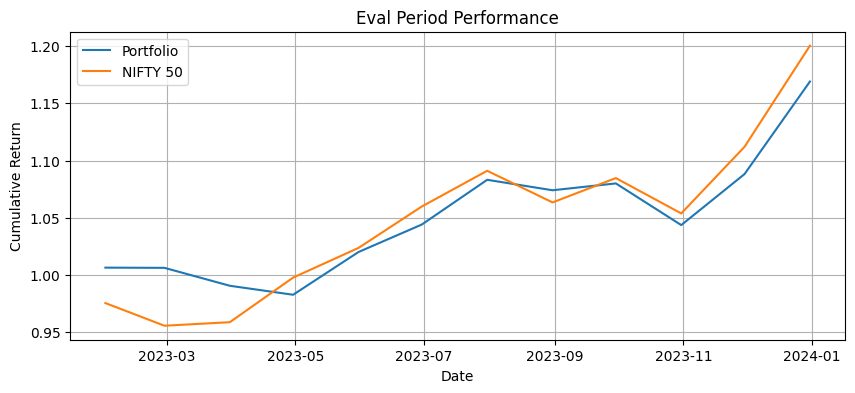


--- Eval Period Metrics ---
Monthly Return: 1.35%
Monthly Volatility: 3.03%
Monthly Sharpe Ratio: 0.2667
Annual Return: 16.21%
Annual Volatility: 10.51%
Annual Sharpe Ratio: 0.9239


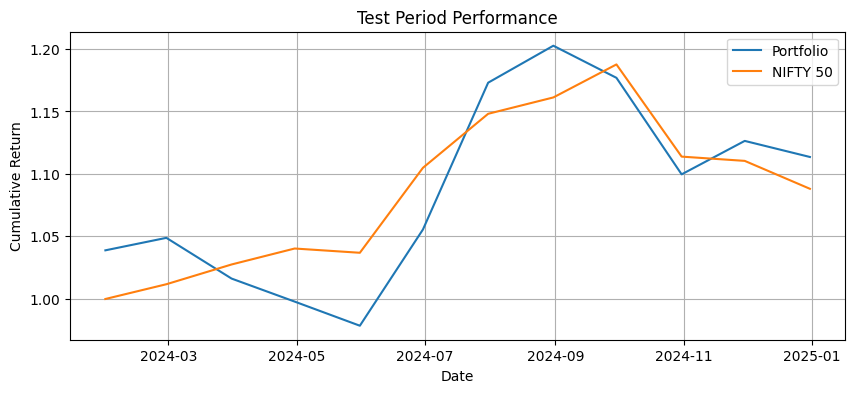


--- Test Period Metrics ---
Monthly Return: 1.01%
Monthly Volatility: 4.94%
Monthly Sharpe Ratio: 0.0946
Annual Return: 12.11%
Annual Volatility: 17.11%
Annual Sharpe Ratio: 0.3278


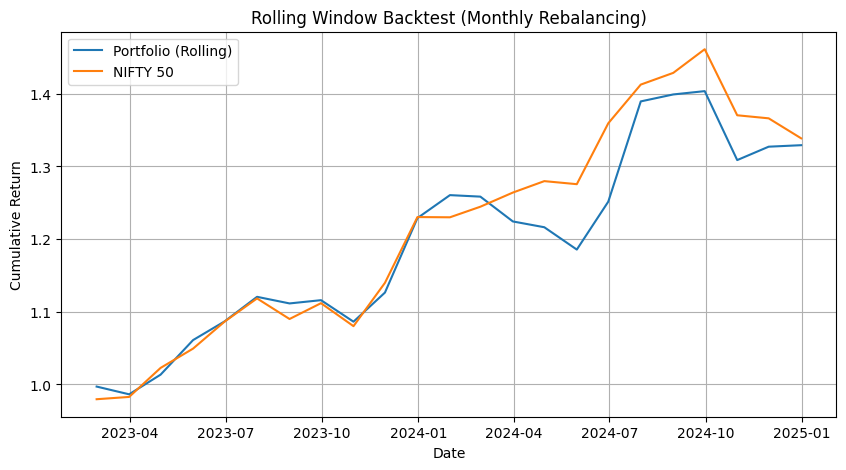


--- Rolling Window Metrics ---
Monthly Return: 1.32%
Monthly Volatility: 3.89%
Sharpe Ratio: 0.1991
Annual Return: 15.79%
Annual Volatility: 13.46%


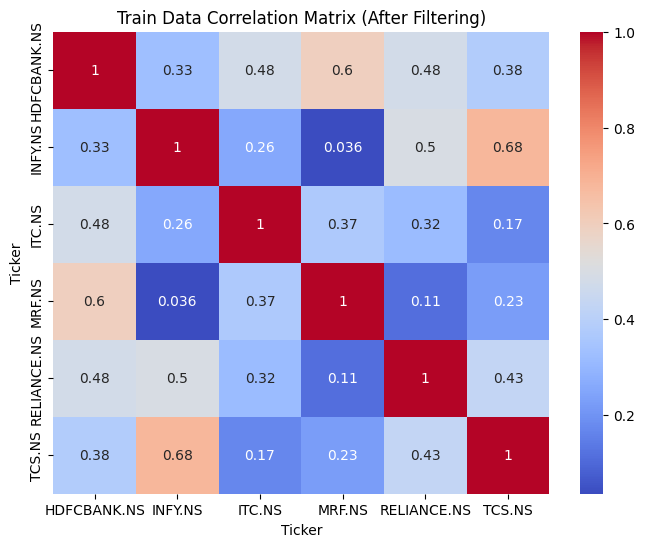

In [4]:
generate_portfolio(['HDFCBANK.NS', 'INFY.NS', 'ITC.NS', 'RELIANCE.NS', 'TCS.NS','MRF.NS'], risk_profile='High')


**Best One******

In [18]:
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.preprocessing import MinMaxScaler

def generate_portfolio(tickers, risk_profile='Medium', start_date='2022-01-01', end_date='2024-12-31', rf_annual=0.065):
    rf_monthly = rf_annual / 12

    # 1. Download stock data
    data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)
    monthly_prices = data['Close'].resample('ME').ffill()
    monthly_returns = monthly_prices.pct_change().dropna()

    # 2. Download market index data
    market = yf.download('^NSEI', start=start_date, end=end_date, auto_adjust=True)
    market_prices = market['Close'].resample('ME').ffill()
    market_returns = market_prices.pct_change().dropna()

    # 3. Align data
    common_index = monthly_returns.index.intersection(market_returns.index)
    monthly_returns_aligned = monthly_returns.loc[common_index]
    market_returns_aligned = market_returns.loc[common_index]
    if isinstance(market_returns_aligned, pd.DataFrame):
        market_returns_aligned = market_returns_aligned.iloc[:, 0]

    # 4. Risk metrics
    mean_return = monthly_returns_aligned.mean()
    std_dev = monthly_returns_aligned.std()
    beta = pd.Series({
        col: monthly_returns_aligned[col].dropna().align(market_returns_aligned.dropna(), join='inner')[0].cov(
            monthly_returns_aligned[col].dropna().align(market_returns_aligned.dropna(), join='inner')[1]
        )
        for col in monthly_returns_aligned.columns
    }) / market_returns_aligned.var()

    treynor = (mean_return - rf_monthly) / beta
    sharpe = (mean_return - rf_monthly) / std_dev

    z_95 = norm.ppf(0.05)
    z_99 = norm.ppf(0.01)
    VaR_95 = mean_return + z_95 * std_dev
    VaR_99 = mean_return + z_99 * std_dev

    # 5. Correlation filtering
    corr_matrix = monthly_returns_aligned.corr()
    def remove_high_corr_stocks(corr_matrix, threshold=0.85):
        to_drop = set()
        for i in corr_matrix.columns:
            for j in corr_matrix.columns:
                if i != j and corr_matrix.loc[i, j] > threshold:
                    if sharpe[i] < sharpe[j]:
                        to_drop.add(i)
                    else:
                        to_drop.add(j)
        return list(to_drop)

    high_corr_stocks = remove_high_corr_stocks(corr_matrix, threshold=0.85)
    print("Removed due to high correlation:", high_corr_stocks)

    # Drop filtered
    monthly_returns_aligned.drop(columns=high_corr_stocks, inplace=True)
    for metric in [mean_return, std_dev, beta, treynor, sharpe, VaR_95, VaR_99]:
        metric.drop(labels=high_corr_stocks, errors='ignore', inplace=True)

    # 6. Create metrics DataFrame
    metrics_df = pd.DataFrame({
        'Return': mean_return,
        'Volatility': std_dev,
        'Beta': beta,
        'Sharpe': sharpe,
        'Treynor': treynor,
        'VaR_95': VaR_95,
        'VaR_99': VaR_99
    })
    metrics_df['-Beta'] = -metrics_df['Beta']
    metrics_df['-VaR_95'] = -metrics_df['VaR_95']
    metrics_df['-Volatility'] = -metrics_df['Volatility']

    # 7. Risk-based metric selection
    if risk_profile == 'Low':
        selected_metrics = ['Sharpe', '-Beta', '-VaR_95', '-Volatility']
    elif risk_profile == 'High':
        selected_metrics = ['Return', 'Sharpe', 'Treynor']
    else:  # Medium
        selected_metrics = ['Sharpe', 'Treynor', '-Beta', '-VaR_95']

    # 8. Normalize & weight
    scaler = MinMaxScaler()
    norm_metrics = scaler.fit_transform(metrics_df[selected_metrics])
    score = norm_metrics.mean(axis=1)
    weights = score / score.sum()

    # 9. Portfolio stats
    portfolio_return = np.dot(weights, mean_return)
    portfolio_std = np.sqrt(np.dot(weights.T, np.dot(monthly_returns_aligned.cov(), weights)))
    portfolio_sharpe = (portfolio_return - rf_monthly) / portfolio_std

    # Annualized
    annual_return = portfolio_return * 12
    annual_std = portfolio_std * np.sqrt(12)
    annual_sharpe = (annual_return - rf_annual) / annual_std

    # 10. Output metrics & visuals
    print("\n=== Final Stock Metrics ===")
    print((metrics_df[['Return', 'Volatility', 'Beta', 'Sharpe', 'Treynor', 'VaR_95', 'VaR_99']] * 100).round(2))

    print("\n=== Portfolio Weights ===")
    print(pd.Series(weights, index=metrics_df.index).round(4))

    print(f"\nPortfolio Monthly Return: {portfolio_return*100:.2f}%")
    print(f"Portfolio Monthly Volatility: {portfolio_std*100:.2f}%")
    print(f"Portfolio Monthly Sharpe Ratio: {portfolio_sharpe:.4f}")
    print(f"\nPortfolio Annualized Return: {annual_return*100:.2f}%")
    print(f"Portfolio Annualized Volatility: {annual_std*100:.2f}%")
    print(f"Portfolio Annualized Sharpe Ratio: {annual_sharpe:.4f}")

    plt.figure(figsize=(8,6))
    sns.heatmap(monthly_returns_aligned.corr(), annot=True, cmap='coolwarm')
    plt.title("Correlation Matrix (After Filtering)")
    plt.show()

    # Pie chart of weights
    plt.figure(figsize=(6,6))
    plt.pie(weights, labels=metrics_df.index, autopct='%1.1f%%', startangle=140)
    plt.title("Portfolio Allocation (Weights)")
    plt.axis('equal')
    plt.show()

    # 11. Backtesting on training period
    portfolio_returns_series = monthly_returns_aligned @ weights
    cumulative_returns = (1 + portfolio_returns_series).cumprod()
    cumulative_market = (1 + market_returns_aligned).cumprod()

    plt.figure(figsize=(10, 5))
    plt.plot(cumulative_returns, label='Your Portfolio')
    plt.plot(cumulative_market, label='NIFTY 50')
    plt.title("Backtest: Portfolio vs NIFTY 50 (Training Period)")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.legend()
    plt.grid(True)
    plt.show()

    # 12. 2025 Testing
    print("\n=== Testing Portfolio Performance on 2025 Data ===")
    start_2025 = '2025-01-01'
    end_2025 = '2025-06-30'     # pd.Timestamp.today().strftime('%Y-%m-%d')
    data_2025 = yf.download(tickers, start=start_2025, end=end_2025, auto_adjust=True)
    prices_2025 = data_2025['Close'].resample('ME').ffill()
    returns_2025 = prices_2025.pct_change().dropna()

    # Filter tickers still in portfolio weights
    valid_tickers = [t for t in metrics_df.index if t in returns_2025.columns]
    returns_2025 = returns_2025[valid_tickers]
    weights_2025 = pd.Series(weights, index=metrics_df.index)[valid_tickers]
    weights_2025 /= weights_2025.sum()  # normalize again

    # Calculate portfolio returns and stats for 2025
    port_returns_2025 = returns_2025 @ weights_2025
    port_cum_2025 = (1 + port_returns_2025).cumprod()

    # Market returns 2025
    market_2025 = yf.download('^NSEI', start=start_2025, end=end_2025, auto_adjust=True)
    market_prices_2025 = market_2025['Close'].resample('ME').ffill()
    market_returns_2025 = market_prices_2025.pct_change().dropna()
    market_cum_2025 = (1 + market_returns_2025).cumprod()

    mean_ret_2025 = port_returns_2025.mean()
    std_ret_2025 = port_returns_2025.std()
    sharpe_2025 = (mean_ret_2025 - rf_monthly) / std_ret_2025
    ann_ret_2025 = mean_ret_2025 * 12
    ann_std_2025 = std_ret_2025 * np.sqrt(12)
    ann_sharpe_2025 = (ann_ret_2025 - rf_annual) / ann_std_2025

    print(f"\n2025 Monthly Return: {mean_ret_2025*100:.2f}%")
    print(f"2025 Monthly Volatility: {std_ret_2025*100:.2f}%")
    print(f"2025 Monthly Sharpe Ratio: {sharpe_2025:.4f}")
    print(f"2025 Annualized Return: {ann_ret_2025*100:.2f}%")
    print(f"2025 Annualized Volatility: {ann_std_2025*100:.2f}%")
    print(f"2025 Annualized Sharpe Ratio: {ann_sharpe_2025:.4f}")

    plt.figure(figsize=(10, 5))
    plt.plot(port_cum_2025, label='Portfolio 2025')
    plt.plot(market_cum_2025, label='NIFTY 50 2025')
    plt.title("Portfolio vs NIFTY 50 Cumulative Return (2025 to Present)")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.grid(True)
    plt.legend()
    plt.show()


    return pd.Series(weights, index=metrics_df.index)


[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  1 of 1 completed


Removed due to high correlation: []

=== Final Stock Metrics ===
             Return  Volatility    Beta  Sharpe  Treynor  VaR_95  VaR_99
INFY.NS        0.74        7.37   96.61    2.71     0.21  -11.38  -16.41
MRF.NS         1.98        7.17  115.23   20.07     1.25   -9.81  -14.69
RELIANCE.NS    0.46        5.82   99.93   -1.35    -0.08   -9.11  -13.08

=== Portfolio Weights ===
INFY.NS        0.1638
MRF.NS         0.8362
RELIANCE.NS    0.0000
dtype: float64

Portfolio Monthly Return: 1.78%
Portfolio Monthly Volatility: 6.53%
Portfolio Monthly Sharpe Ratio: 0.1892

Portfolio Annualized Return: 21.33%
Portfolio Annualized Volatility: 22.63%
Portfolio Annualized Sharpe Ratio: 0.6553


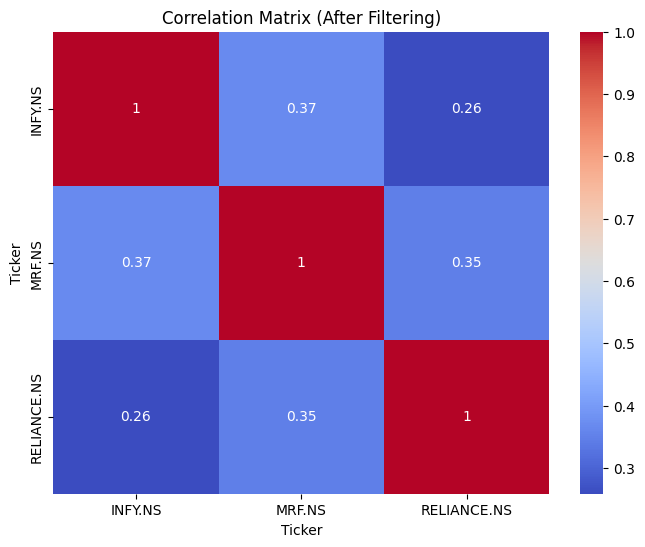

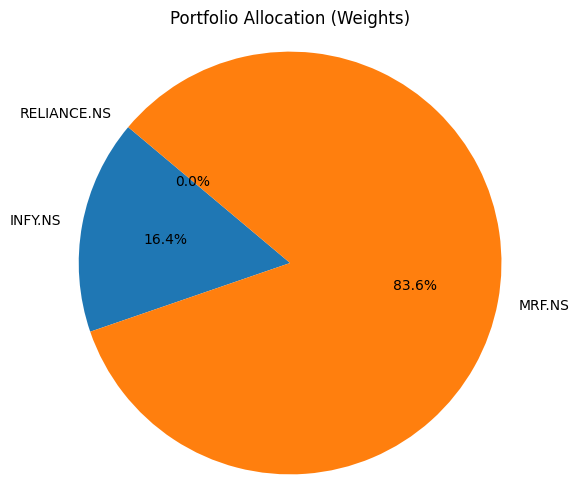

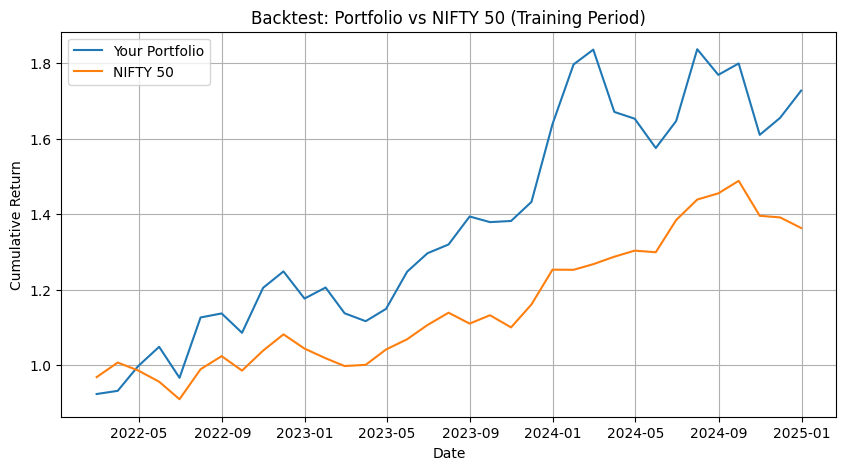

[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  1 of 1 completed


=== Testing Portfolio Performance on 2025 Data ===

2025 Monthly Return: 3.82%
2025 Monthly Volatility: 8.23%
2025 Monthly Sharpe Ratio: 0.3986
2025 Annualized Return: 45.84%
2025 Annualized Volatility: 28.50%
2025 Annualized Sharpe Ratio: 1.3807


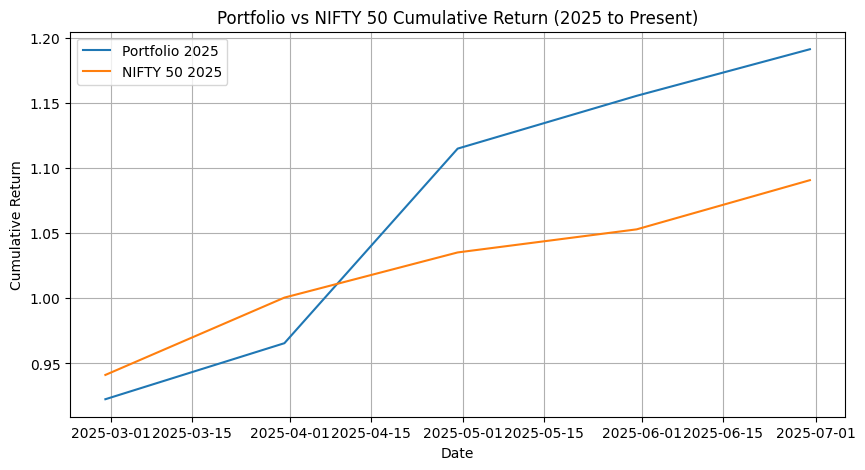

INFY.NS        0.163811
MRF.NS         0.836189
RELIANCE.NS    0.000000
dtype: float64

In [20]:
generate_portfolio(['INFY.NS', 'RELIANCE.NS','MRF.NS'], risk_profile='High')
